In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/hotel_bookings 2.csv")

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/7/2015


In [6]:
#basic inpection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [8]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

categorical_cols = df.select_dtypes(
    include="object"
).columns

print("Numerical columns:")
print(numeric_cols.tolist())

print("\nCategorical columns:")
print(categorical_cols.tolist())

Numerical columns:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


In [74]:
df.duplicated().sum()

np.int64(31994)

In [75]:
df[df.duplicated()].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay,lead_time_group,previous_cancel_group
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.00,0,1,Check-Out,3/7/2015,2,8-30 days,0
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,0,Transient,84.67,0,1,Check-Out,7/7/2015,6,31-90 days,0
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,0,Transient,137.00,0,1,Check-Out,7/7/2015,5,31-90 days,0
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,0,Transient,97.00,0,0,Canceled,1/7/2015,1,0-7 days,0
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,0,Transient,109.80,0,3,Check-Out,8/7/2015,1,0-7 days,0


In [76]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing = missing[
    missing["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)

missing

,missing_count,missing_percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


In [12]:
df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [13]:
df["is_canceled"].value_counts(
    normalize=True
) * 100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

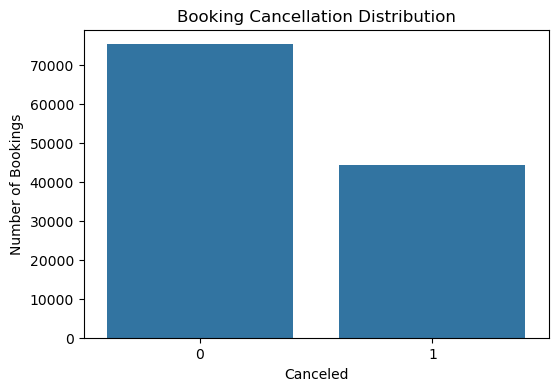

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="is_canceled"
)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Canceled")
plt.ylabel("Number of Bookings")

plt.show()


#### cancellation rate by hotel

In [15]:
hotel_cancel = df.groupby(
    "hotel"
)["is_canceled"].mean().sort_values(
    ascending=False
)

hotel_cancel

hotel
City Hotel      0.417270
Resort Hotel    0.277634
Name: is_canceled, dtype: float64

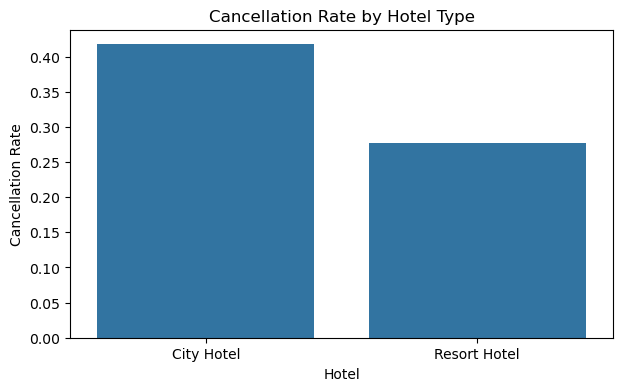

In [16]:
plt.figure(figsize=(7,4))

sns.barplot(
    x=hotel_cancel.index,
    y=hotel_cancel.values
)

plt.title("Cancellation Rate by Hotel Type")
plt.ylabel("Cancellation Rate")
plt.xlabel("Hotel")

plt.show()

In [17]:
df.groupby(
    "is_canceled"
)["lead_time"].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,79.984687,91.109888,0.0,9.0,45.0,124.0,737.0
1,44224.0,144.848815,118.624829,0.0,48.0,113.0,214.0,629.0


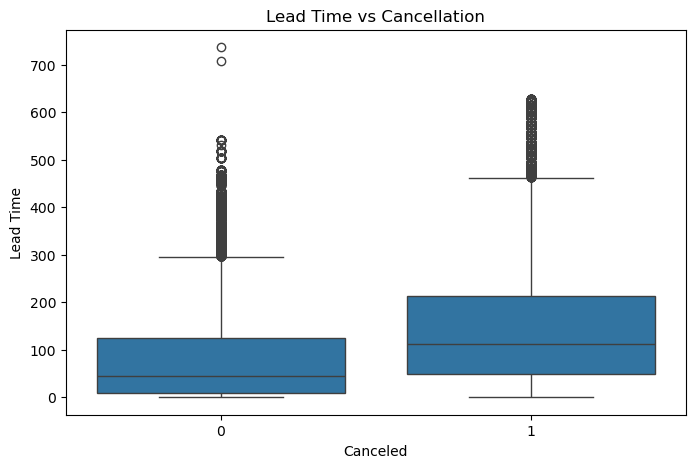

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="lead_time"
)

plt.title("Lead Time vs Cancellation")
plt.xlabel("Canceled")
plt.ylabel("Lead Time")

plt.show()

In [19]:
df.groupby(
    "is_canceled"
)["lead_time"].median()

is_canceled
0     45.0
1    113.0
Name: lead_time, dtype: float64

In [20]:
deposit_cancel = pd.crosstab(
    df["deposit_type"],
    df["is_canceled"],
    normalize="index"
)

deposit_cancel

is_canceled,0,1
deposit_type,,
No Deposit,0.716230,0.283770
Non Refund,0.006376,0.993624
Refundable,0.777778,0.222222


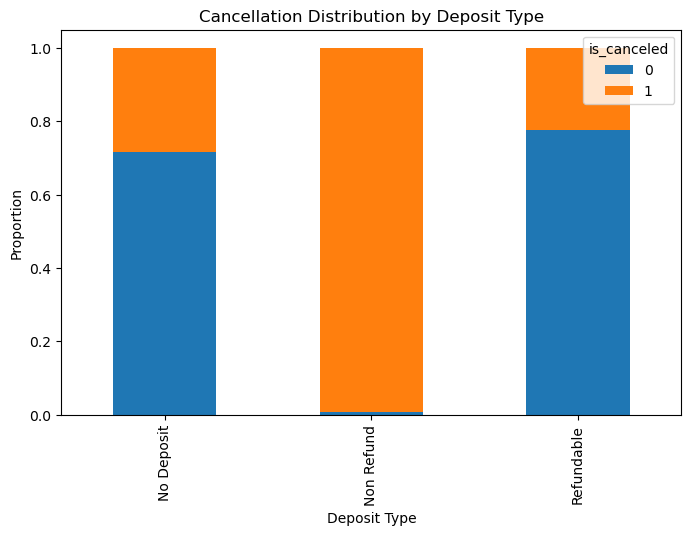

In [21]:
deposit_cancel.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Cancellation Distribution by Deposit Type")
plt.ylabel("Proportion")
plt.xlabel("Deposit Type")

plt.show()

In [22]:
market_cancel = df.groupby(
    "market_segment"
)["is_canceled"].mean().sort_values(
    ascending=False
)

market_cancel

market_segment
Undefined        1.000000
Groups           0.610620
Online TA        0.367211
Offline TA/TO    0.343160
Aviation         0.219409
Corporate        0.187347
Direct           0.153419
Complementary    0.130552
Name: is_canceled, dtype: float64

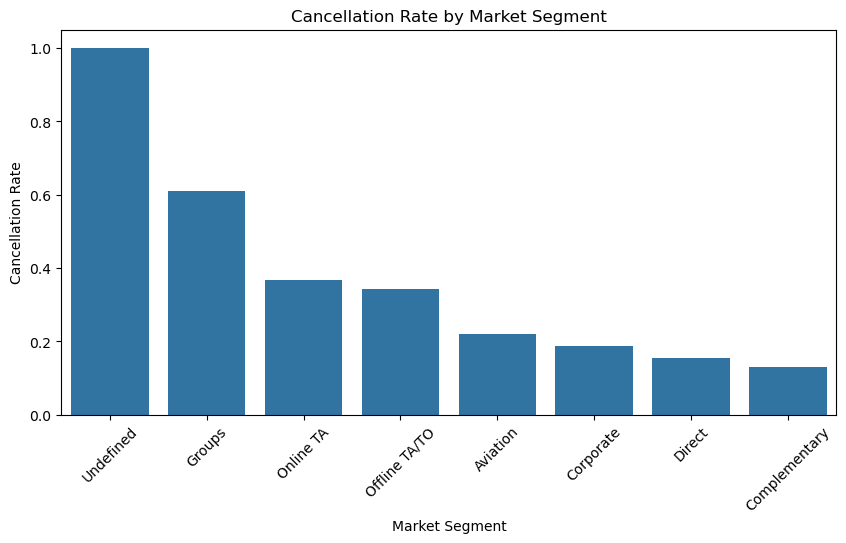

In [23]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=market_cancel.index,
    y=market_cancel.values
)

plt.xticks(rotation=45)

plt.title("Cancellation Rate by Market Segment")
plt.ylabel("Cancellation Rate")
plt.xlabel("Market Segment")

plt.show()

In [24]:
customer_cancel = df.groupby(
    "customer_type"
)["is_canceled"].mean().sort_values(
    ascending=False
)

customer_cancel

customer_type
Transient          0.407463
Contract           0.309617
Transient-Party    0.254299
Group              0.102253
Name: is_canceled, dtype: float64

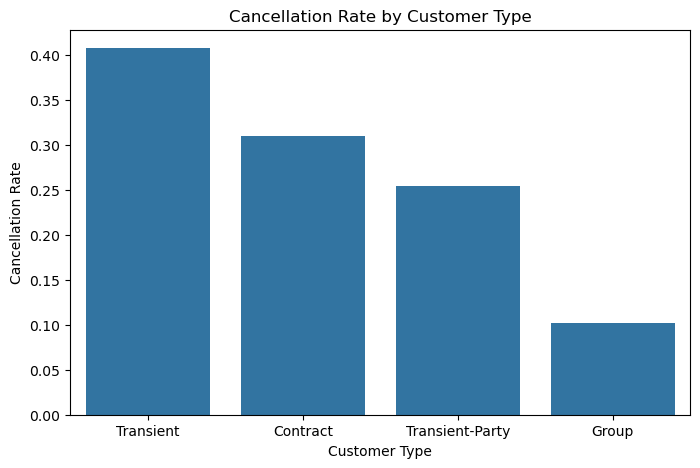

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=customer_cancel.index,
    y=customer_cancel.values
)

plt.title("Cancellation Rate by Customer Type")
plt.ylabel("Cancellation Rate")
plt.xlabel("Customer Type")

plt.show()

In [26]:
df.groupby(
    "previous_cancellations"
)["is_canceled"].mean().head(15)

previous_cancellations
0     0.339061
1     0.944307
2     0.327586
3     0.307692
4     0.225806
5     0.105263
6     0.318182
11    0.285714
13    0.916667
14    1.000000
19    1.000000
21    1.000000
24    1.000000
25    1.000000
26    1.000000
Name: is_canceled, dtype: float64

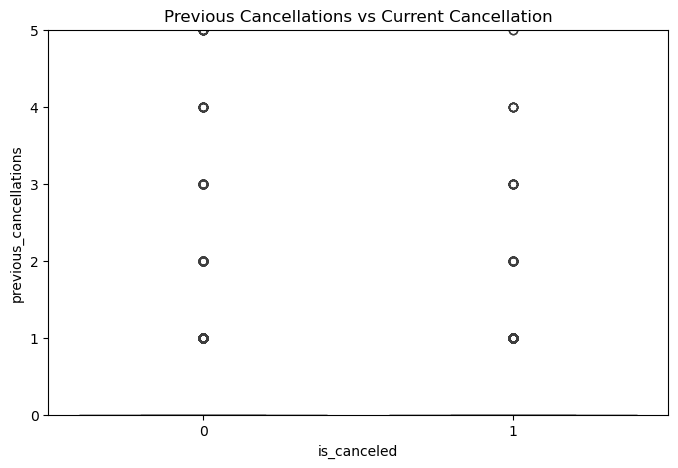

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="previous_cancellations"
)

plt.ylim(0, 5)

plt.title("Previous Cancellations vs Current Cancellation")
plt.show()

In [31]:
special_request_cancel = df.groupby(
    "total_of_special_requests"
)["is_canceled"].mean()*100

In [32]:
special_request_cancel

total_of_special_requests
0    47.720356
1    22.024920
2    22.098851
3    17.861434
4    10.588235
5     5.000000
Name: is_canceled, dtype: float64

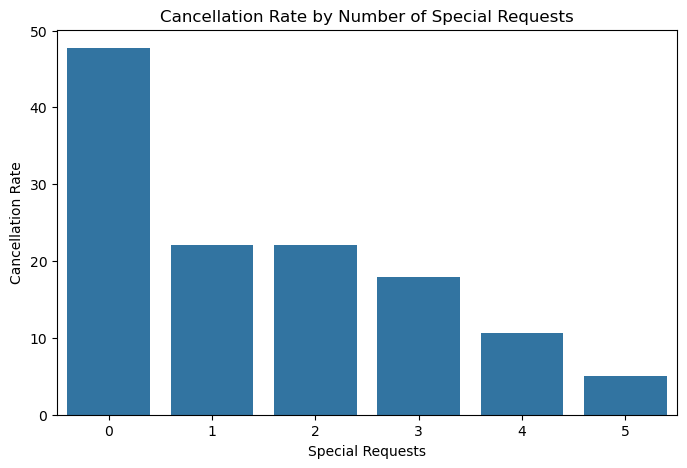

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=special_request_cancel.index,
    y=special_request_cancel.values
)

plt.title("Cancellation Rate by Number of Special Requests")
plt.ylabel("Cancellation Rate")
plt.xlabel("Special Requests")

plt.show()

In [34]:
df.groupby(
    "is_canceled"
)["adr"].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,99.987693,49.206263,-6.38,67.500,92.5,125.00,510.0
1,44224.0,104.964333,52.571142,0.00,72.415,96.2,127.62,5400.0


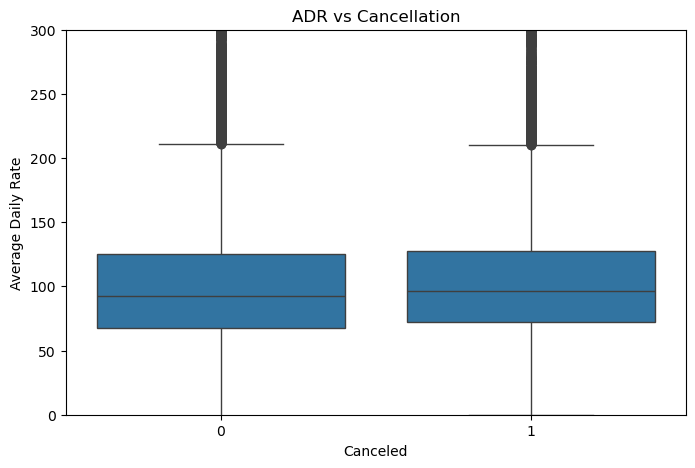

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="adr"
)

plt.ylim(0, 300)

plt.title("ADR vs Cancellation")
plt.ylabel("Average Daily Rate")
plt.xlabel("Canceled")

plt.show()

In [36]:
df["adr"].min(), df["adr"].max()

(-6.38, 5400.0)

In [38]:
df[df["adr"] <= 0][
    ["hotel", "is_canceled", "adr", "adults",
     "children", "babies"]
].head()

,hotel,is_canceled,adr,adults,children,babies
0,Resort Hotel,0,0.0,2,0.0,0
1,Resort Hotel,0,0.0,2,0.0,0
125,Resort Hotel,0,0.0,4,0.0,0
167,Resort Hotel,0,0.0,2,0.0,0
168,Resort Hotel,0,0.0,1,0.0,0


In [39]:
df["total_stay"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

In [40]:
df.groupby(
    "is_canceled"
)["total_stay"].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,3.393023,2.577671,0.0,2.0,3.0,4.0,69.0
1,44224.0,3.487179,2.521601,0.0,2.0,3.0,4.0,56.0


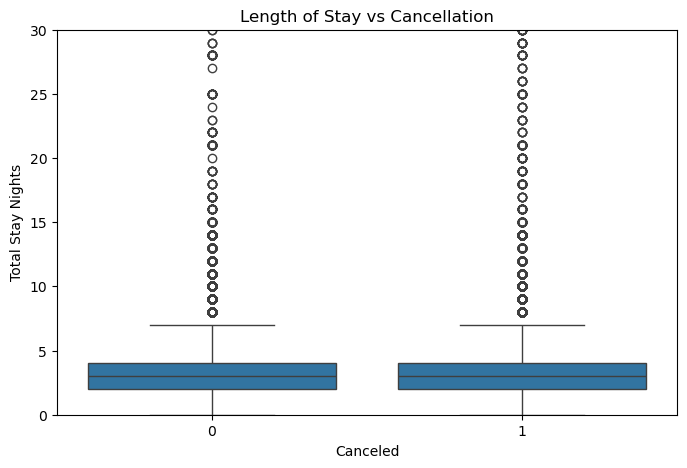

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="total_stay"
)

plt.ylim(0, 30)

plt.title("Length of Stay vs Cancellation")
plt.ylabel("Total Stay Nights")
plt.xlabel("Canceled")

plt.show()

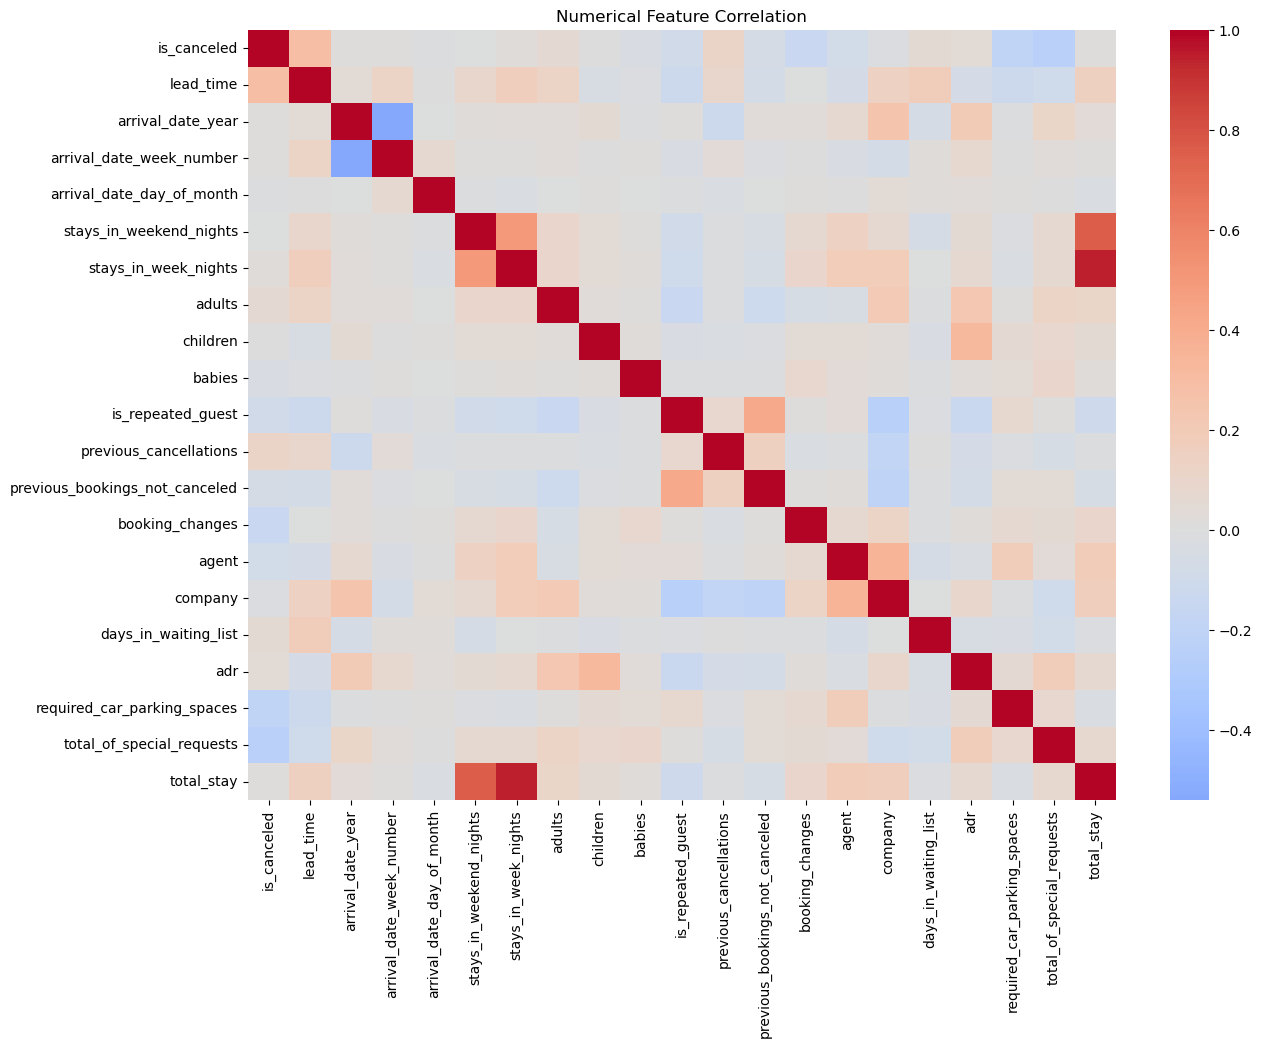

In [42]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation")

plt.show()

In [43]:
month_cancel = df.groupby(
    "arrival_date_month"
)["is_canceled"].mean()

In [44]:
month_order = [
    "January", "February", "March",
    "April", "May", "June",
    "July", "August", "September",
    "October", "November", "December"
]

In [45]:
month_cancel = (
    df.groupby("arrival_date_month")["is_canceled"]
    .mean()
    .reindex(month_order)
)

month_cancel

arrival_date_month
January      0.304773
February     0.334160
March        0.321523
April        0.407972
May          0.396658
June         0.414572
July         0.374536
August       0.377531
September    0.391702
October      0.380466
November     0.312334
December     0.349705
Name: is_canceled, dtype: float64

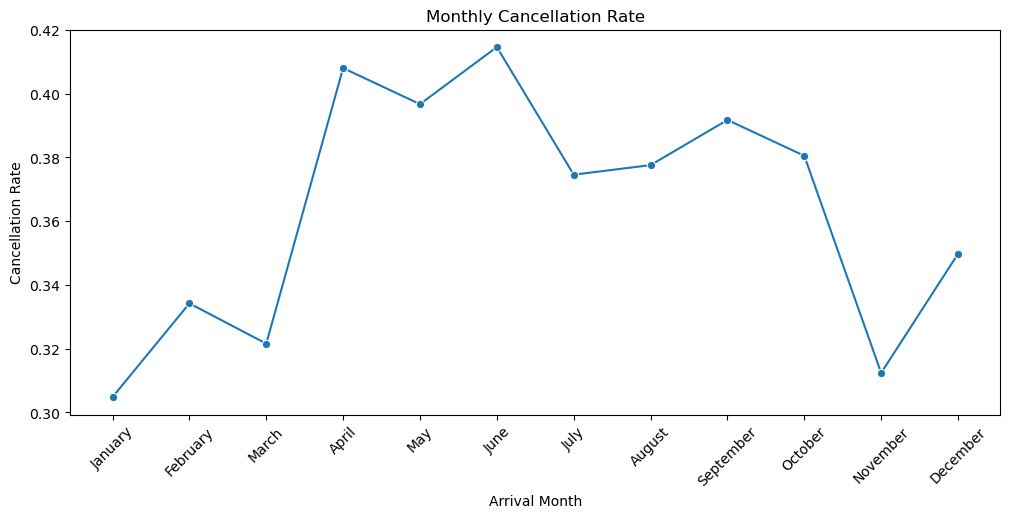

In [46]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=month_cancel.index,
    y=month_cancel.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Cancellation Rate")
plt.ylabel("Cancellation Rate")
plt.xlabel("Arrival Month")

plt.show()

In [47]:
df.groupby(df.duplicated())["is_canceled"].value_counts(
    normalize=True
)

       is_canceled
False  0              0.725102
       1              0.274898
True   1              0.631337
       0              0.368663
Name: proportion, dtype: float64

In [48]:
df[df["adr"] <= 0][
    ["hotel", "is_canceled", "lead_time",
     "adults", "children", "babies", "adr"]
]

,hotel,is_canceled,lead_time,adults,children,babies,adr
0,Resort Hotel,0,342,2,0.0,0,0.0
1,Resort Hotel,0,737,2,0.0,0,0.0
125,Resort Hotel,0,32,4,0.0,0,0.0
167,Resort Hotel,0,111,2,0.0,0,0.0
168,Resort Hotel,0,0,1,0.0,0,0.0
...,...,...,...,...,...,...,...
118631,City Hotel,0,78,1,0.0,0,0.0
118762,City Hotel,0,1,2,1.0,0,0.0
118963,City Hotel,0,1,2,0.0,0,0.0
119102,City Hotel,0,518,1,0.0,0,0.0


In [49]:
df[df["adr"] > 1000][
    ["hotel", "is_canceled", "lead_time",
     "adults", "children", "babies", "adr"]
].sort_values("adr", ascending=False)

,hotel,is_canceled,lead_time,adults,children,babies,adr
48515,City Hotel,1,35,2,0.0,0,5400.0


In [50]:
df[df["adults"] > 10][
    ["hotel", "adults", "children", "babies",
     "is_canceled", "adr"]
].sort_values("adults", ascending=False)

,hotel,adults,children,babies,is_canceled,adr
2173,Resort Hotel,55,0.0,0,1,0.0
1643,Resort Hotel,50,0.0,0,1,0.0
1539,Resort Hotel,40,0.0,0,1,0.0
1917,Resort Hotel,27,0.0,0,1,0.0
1962,Resort Hotel,27,0.0,0,1,0.0
1587,Resort Hotel,26,0.0,0,1,0.0
1752,Resort Hotel,26,0.0,0,1,0.0
1884,Resort Hotel,26,0.0,0,1,0.0
2003,Resort Hotel,26,0.0,0,1,0.0
2164,Resort Hotel,26,0.0,0,1,0.0


In [51]:
df[df["adr"] == 5400]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay
48515,City Hotel,1,35,2016,March,13,25,0,1,2,...,12.0,NaN,0,Transient,5400.0,0,0,Canceled,19/2/2016,1


In [52]:
df[df["adr"] > 500][
    ["hotel", "is_canceled", "lead_time",
     "adults", "children", "babies",
     "stays_in_weekend_nights",
     "stays_in_week_nights",
     "adr"]
].sort_values("adr", ascending=False)

,hotel,is_canceled,lead_time,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,adr
48515,City Hotel,1,35,2,0.0,0,0,1,5400.0
111403,City Hotel,0,0,1,0.0,0,0,1,510.0
15083,Resort Hotel,0,1,2,0.0,0,0,1,508.0


In [53]:
df[df["adults"] > 10].shape

(12, 33)

In [54]:
df[df["adults"] > 10]["is_canceled"].value_counts(
    normalize=True
)

is_canceled
1    1.0
Name: proportion, dtype: float64

In [55]:
df[df["adults"] > 10][
    [
        "hotel",
        "is_canceled",
        "lead_time",
        "adults",
        "children",
        "babies",
        "adr",
        "market_segment",
        "customer_type"
    ]
].sort_values("adults", ascending=False)

,hotel,is_canceled,lead_time,adults,children,babies,adr,market_segment,customer_type
2173,Resort Hotel,1,338,55,0.0,0,0.0,Direct,Group
1643,Resort Hotel,1,336,50,0.0,0,0.0,Direct,Group
1539,Resort Hotel,1,304,40,0.0,0,0.0,Direct,Group
1917,Resort Hotel,1,349,27,0.0,0,0.0,Direct,Group
1962,Resort Hotel,1,352,27,0.0,0,0.0,Direct,Group
1587,Resort Hotel,1,333,26,0.0,0,0.0,Offline TA/TO,Group
1752,Resort Hotel,1,340,26,0.0,0,0.0,Offline TA/TO,Group
1884,Resort Hotel,1,347,26,0.0,0,0.0,Offline TA/TO,Group
2003,Resort Hotel,1,354,26,0.0,0,0.0,Offline TA/TO,Group
2164,Resort Hotel,1,361,26,0.0,0,0.0,Offline TA/TO,Group


In [56]:
zero_guests = df[
    (df["adults"] == 0) &
    (df["children"].fillna(0) == 0) &
    (df["babies"] == 0)
]

zero_guests.shape

(180, 33)

In [57]:
zero_guests = df[
    (df["adults"] == 0) &
    (df["children"].fillna(0) == 0) &
    (df["babies"] == 0)
]

zero_guests.shape

(180, 33)

In [58]:
zero_guests[
    [
        "hotel",
        "is_canceled",
        "lead_time",
        "adr",
        "market_segment",
        "customer_type"
    ]
].head(20)

,hotel,is_canceled,lead_time,adr,market_segment,customer_type
2224,Resort Hotel,0,1,0.0,Corporate,Transient-Party
2409,Resort Hotel,0,0,0.0,Corporate,Transient
3181,Resort Hotel,0,36,0.0,Groups,Transient-Party
3684,Resort Hotel,0,165,0.0,Groups,Transient-Party
3708,Resort Hotel,0,165,0.0,Groups,Transient-Party
4127,Resort Hotel,1,0,0.0,Offline TA/TO,Transient
9376,Resort Hotel,1,0,0.0,Offline TA/TO,Group
31765,Resort Hotel,0,31,28.0,Direct,Transient
32029,Resort Hotel,0,4,0.0,Groups,Transient-Party
32827,Resort Hotel,0,46,0.0,Direct,Transient


In [59]:
df.groupby("is_canceled")["lead_time"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
is_canceled,,,,,,
0,75166,79.984687,45.0,91.109888,0,737
1,44224,144.848815,113.0,118.624829,0,629


In [60]:
df["lead_time_group"] = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, 1000],
    labels=[
        "0-7 days",
        "8-30 days",
        "31-90 days",
        "91-180 days",
        "181-365 days",
        "365+ days"
    ]
)

In [62]:
lead_cancel = df.groupby(
    "lead_time_group",
    observed=False
)["is_canceled"].mean()

lead_cancel

lead_time_group
0-7 days        0.096323
8-30 days       0.278639
31-90 days      0.376984
91-180 days     0.447105
181-365 days    0.554540
365+ days       0.676620
Name: is_canceled, dtype: float64

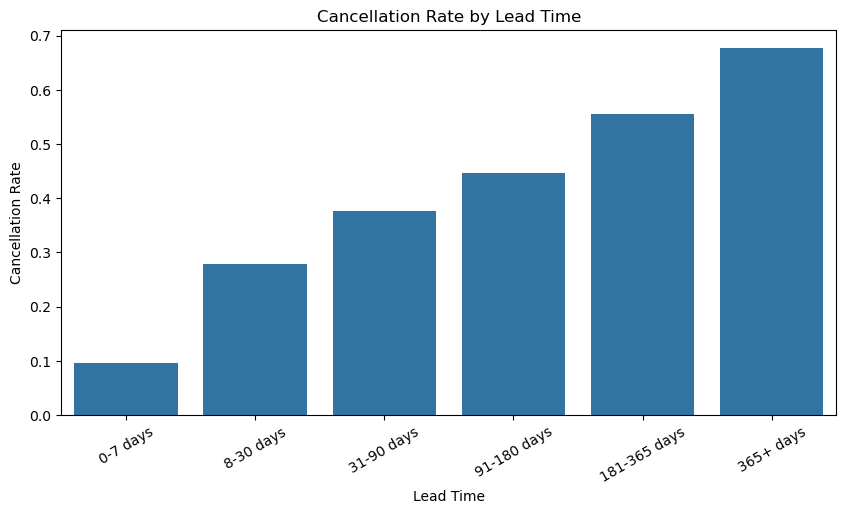

In [63]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=lead_cancel.index,
    y=lead_cancel.values
)

plt.title("Cancellation Rate by Lead Time")
plt.xlabel("Lead Time")
plt.ylabel("Cancellation Rate")

plt.xticks(rotation=30)
plt.show()

In [64]:
df.groupby("deposit_type")["is_canceled"].agg(
    ["count", "mean"]
).sort_values("mean", ascending=False)

,count,mean
deposit_type,,
Non Refund,14587,0.993624
No Deposit,104641,0.283770
Refundable,162,0.222222


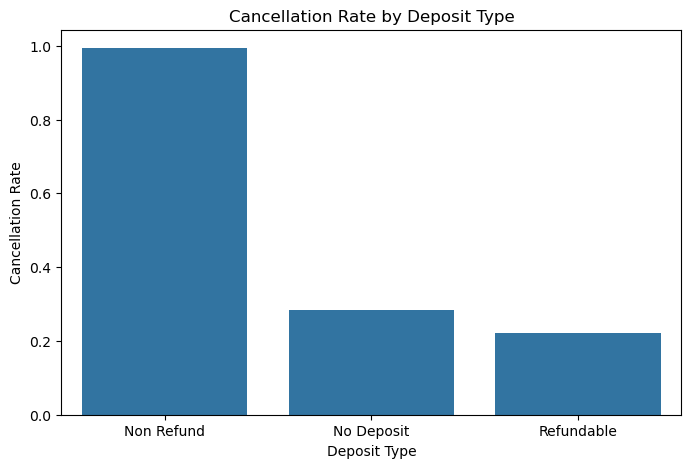

In [65]:
deposit_cancel = df.groupby(
    "deposit_type"
)["is_canceled"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=deposit_cancel.index,
    y=deposit_cancel.values
)

plt.title("Cancellation Rate by Deposit Type")
plt.ylabel("Cancellation Rate")
plt.xlabel("Deposit Type")

plt.show()

In [66]:
market_cancel = df.groupby(
    "market_segment"
)["is_canceled"].agg(
    ["count", "mean"]
).sort_values(
    "mean",
    ascending=False
)

market_cancel

,count,mean
market_segment,,
Undefined,2,1.000000
Groups,19811,0.610620
Online TA,56477,0.367211
Offline TA/TO,24219,0.343160
Aviation,237,0.219409
Corporate,5295,0.187347
Direct,12606,0.153419
Complementary,743,0.130552


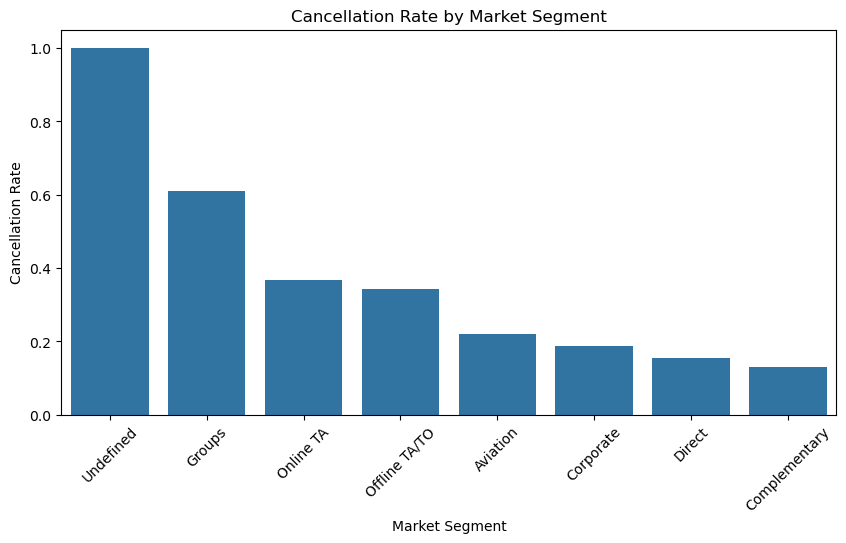

In [67]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=market_cancel.reset_index(),
    x="market_segment",
    y="mean"
)

plt.xticks(rotation=45)
plt.ylabel("Cancellation Rate")
plt.xlabel("Market Segment")
plt.title("Cancellation Rate by Market Segment")

plt.show()

In [68]:
df["previous_cancel_group"] = pd.cut(
    df["previous_cancellations"],
    bins=[-1, 0, 1, 3, 100],
    labels=[
        "0",
        "1",
        "2-3",
        "4+"
    ]
)

In [69]:
df.groupby(
    "previous_cancel_group",
    observed=False
)["is_canceled"].agg(
    ["count", "mean"]
)

,count,mean
previous_cancel_group,,
0,112906,0.339061
1,6051,0.944307
2-3,181,0.320442
4+,252,0.674603


In [70]:
df.groupby(
    "total_of_special_requests"
)["is_canceled"].agg(
    ["count", "mean"]
)

,count,mean
total_of_special_requests,,
0,70318,0.477204
1,33226,0.220249
2,12969,0.220989
3,2497,0.178614
4,340,0.105882
5,40,0.050000


In [71]:
df.groupby(
    "customer_type"
)["is_canceled"].agg(
    ["count", "mean"]
).sort_values(
    "mean",
    ascending=False
)

,count,mean
customer_type,,
Transient,89613,0.407463
Contract,4076,0.309617
Transient-Party,25124,0.254299
Group,577,0.102253


In [72]:
month_order = [
    "January", "February", "March",
    "April", "May", "June",
    "July", "August", "September",
    "October", "November", "December"
]

month_cancel = (
    df.groupby("arrival_date_month")["is_canceled"]
    .mean()
    .reindex(month_order)
)

month_cancel

arrival_date_month
January      0.304773
February     0.334160
March        0.321523
April        0.407972
May          0.396658
June         0.414572
July         0.374536
August       0.377531
September    0.391702
October      0.380466
November     0.312334
December     0.349705
Name: is_canceled, dtype: float64

In [77]:
zero_guests[[
    "hotel",
    "is_canceled",
    "lead_time",
    "adr",
    "market_segment",
    "distribution_channel",
    "customer_type",
    "reservation_status"
]].value_counts()

hotel         is_canceled  lead_time  adr  market_segment  distribution_channel  customer_type    reservation_status
City Hotel    0            0          0.0  Online TA       TA/TO                 Transient        Check-Out             29
                                           Offline TA/TO   TA/TO                 Transient        Check-Out             12
                                           Direct          Direct                Transient        Check-Out              7
              1            0          0.0  Complementary   Corporate             Transient        Canceled               7
                           244        0.0  Offline TA/TO   TA/TO                 Transient        Canceled               5
                                                                                                                        ..
              0            7          0.0  Online TA       TA/TO                 Transient        Check-Out              1
                      

In [78]:
zero_guests["is_canceled"].value_counts(normalize=True) * 100

is_canceled
0    86.111111
1    13.888889
Name: proportion, dtype: float64

In [79]:
df[df["adults"] > 10].shape

(12, 35)

In [80]:
adult_anomalies = df[df["adults"] > 10].copy()

adult_anomalies[[
    "hotel",
    "is_canceled",
    "lead_time",
    "adults",
    "children",
    "babies",
    "adr",
    "market_segment",
    "distribution_channel",
    "customer_type"
]].sort_values("adults", ascending=False)

,hotel,is_canceled,lead_time,adults,children,babies,adr,market_segment,distribution_channel,customer_type
2173,Resort Hotel,1,338,55,0.0,0,0.0,Direct,Direct,Group
1643,Resort Hotel,1,336,50,0.0,0,0.0,Direct,Direct,Group
1539,Resort Hotel,1,304,40,0.0,0,0.0,Direct,Direct,Group
1917,Resort Hotel,1,349,27,0.0,0,0.0,Direct,Direct,Group
1962,Resort Hotel,1,352,27,0.0,0,0.0,Direct,Direct,Group
1587,Resort Hotel,1,333,26,0.0,0,0.0,Offline TA/TO,TA/TO,Group
1752,Resort Hotel,1,340,26,0.0,0,0.0,Offline TA/TO,TA/TO,Group
1884,Resort Hotel,1,347,26,0.0,0,0.0,Offline TA/TO,TA/TO,Group
2003,Resort Hotel,1,354,26,0.0,0,0.0,Offline TA/TO,TA/TO,Group
2164,Resort Hotel,1,361,26,0.0,0,0.0,Offline TA/TO,TA/TO,Group


In [81]:
adult_anomalies["adults"].value_counts().sort_index()

adults
20    2
26    5
27    2
40    1
50    1
55    1
Name: count, dtype: int64

In [82]:
adult_anomalies.groupby("adults")["is_canceled"].agg(
    ["count", "mean"]
)

,count,mean
adults,,
20,2,1.0
26,5,1.0
27,2,1.0
40,1,1.0
50,1,1.0
55,1,1.0


In [83]:
df["adr"].min(), df["adr"].max()

(-6.38, 5400.0)

In [84]:
adr_summary = pd.DataFrame({
    "range": [
        "ADR <= 0",
        "0 < ADR <= 100",
        "100 < ADR <= 500",
        "500 < ADR <= 1000",
        "ADR > 1000"
    ],
    "count": [
        (df["adr"] <= 0).sum(),
        ((df["adr"] > 0) & (df["adr"] <= 100)).sum(),
        ((df["adr"] > 100) & (df["adr"] <= 500)).sum(),
        ((df["adr"] > 500) & (df["adr"] <= 1000)).sum(),
        (df["adr"] > 1000).sum()
    ]
})

adr_summary

,range,count
0,ADR <= 0,1960
1,0 < ADR <= 100,65678
2,100 < ADR <= 500,51749
3,500 < ADR <= 1000,2
4,ADR > 1000,1


In [85]:
df[df["adr"] > 1000][[
    "hotel",
    "is_canceled",
    "lead_time",
    "adults",
    "children",
    "babies",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adr"
]].sort_values("adr", ascending=False)

,hotel,is_canceled,lead_time,adults,children,babies,stays_in_weekend_nights,stays_in_week_nights,adr
48515,City Hotel,1,35,2,0.0,0,0,1,5400.0


In [86]:
df[df["adr"] == 5400]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay,lead_time_group,previous_cancel_group
48515,City Hotel,1,35,2016,March,13,25,0,1,2,...,0,Transient,5400.0,0,0,Canceled,19/2/2016,1,31-90 days,0


In [87]:
df[
    (df["adults"] == 0) &
    (df["children"].fillna(0) > 0)
][[
    "hotel",
    "adults",
    "children",
    "babies",
    "is_canceled",
    "adr"
]]

,hotel,adults,children,babies,is_canceled,adr
40984,City Hotel,0,3.0,0,0,9.00
41048,City Hotel,0,2.0,0,0,6.00
41446,City Hotel,0,2.0,0,0,6.00
41952,City Hotel,0,2.0,0,0,0.00
45158,City Hotel,0,2.0,0,1,6.00
...,...,...,...,...,...,...
117204,City Hotel,0,2.0,0,0,98.85
117274,City Hotel,0,2.0,0,0,93.64
117303,City Hotel,0,2.0,0,0,98.85
117453,City Hotel,0,2.0,0,0,121.88


In [88]:
df[
    (df["adults"] == 0) &
    (df["babies"] > 0)
][[
    "hotel",
    "adults",
    "children",
    "babies",
    "is_canceled",
    "adr"
]]

,hotel,adults,children,babies,is_canceled,adr
46150,City Hotel,0,2.0,1,0,77.00
81375,City Hotel,0,2.0,1,1,80.75
90790,City Hotel,0,2.0,1,0,116.49


In [89]:
df["total_guests"] = (
    df["adults"] +
    df["children"].fillna(0) +
    df["babies"]
)

In [90]:
df["total_guests"].describe()

count    119390.000000
mean          1.968239
std           0.722394
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          55.000000
Name: total_guests, dtype: float64

In [91]:
df[df["total_guests"] > 10][[
    "hotel",
    "adults",
    "children",
    "babies",
    "total_guests",
    "adr",
    "is_canceled"
]].sort_values("total_guests", ascending=False)

,hotel,adults,children,babies,total_guests,adr,is_canceled
2173,Resort Hotel,55,0.0,0,55.0,0.00,1
1643,Resort Hotel,50,0.0,0,50.0,0.00,1
1539,Resort Hotel,40,0.0,0,40.0,0.00,1
1917,Resort Hotel,27,0.0,0,27.0,0.00,1
1962,Resort Hotel,27,0.0,0,27.0,0.00,1
1587,Resort Hotel,26,0.0,0,26.0,0.00,1
1752,Resort Hotel,26,0.0,0,26.0,0.00,1
1884,Resort Hotel,26,0.0,0,26.0,0.00,1
2003,Resort Hotel,26,0.0,0,26.0,0.00,1
2164,Resort Hotel,26,0.0,0,26.0,0.00,1


In [92]:
booking_changes_cancel = df.groupby(
    "booking_changes"
)["is_canceled"].agg(
    ["count", "mean"]
)

booking_changes_cancel

,count,mean
booking_changes,,
0,101314,0.408542
1,12701,0.142272
2,3805,0.201314
3,927,0.155340
4,376,0.178191
5,118,0.169492
6,63,0.285714
7,31,0.096774
8,17,0.235294


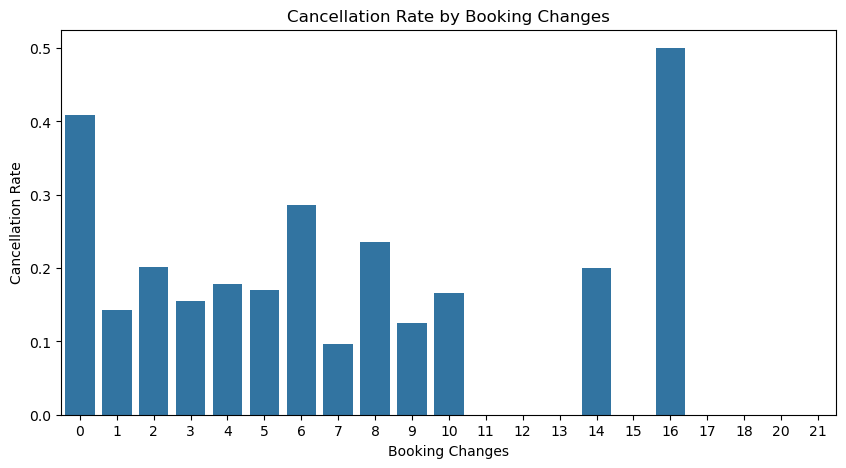

In [93]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=booking_changes_cancel.index,
    y=booking_changes_cancel["mean"]
)

plt.title("Cancellation Rate by Booking Changes")
plt.xlabel("Booking Changes")
plt.ylabel("Cancellation Rate")

plt.show()

In [94]:
guest_cancel = df.groupby(
    "total_guests"
)["is_canceled"].agg(
    ["count", "mean"]
)

guest_cancel.head(20)

,count,mean
total_guests,,
0.0,180,0.138889
1.0,22581,0.290288
2.0,82051,0.396973
3.0,10495,0.321772
4.0,3929,0.418936
5.0,137,0.248175
6.0,1,1.000000
10.0,2,0.500000
12.0,2,0.500000


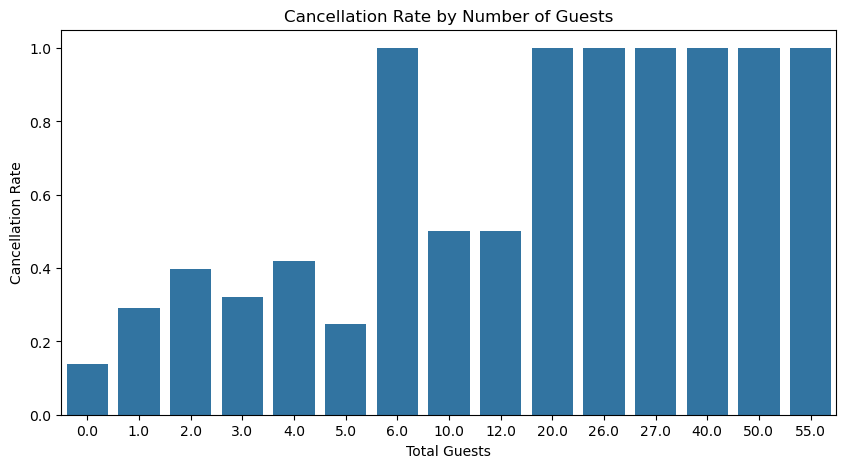

In [95]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=guest_cancel.index,
    y=guest_cancel["mean"]
)

plt.title("Cancellation Rate by Number of Guests")
plt.xlabel("Total Guests")
plt.ylabel("Cancellation Rate")

plt.show()